# Visualize chosem MEI order 

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pickle
import sys

repo_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/"
sys.path.append(repo_path)

import thesis.code.validate_online_meis.utils as ut

In [ ]:
from thesis.code.plot import plot as plotter

plotter.set_default_params(kind='paper')

In [4]:
DATA_DIR = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/validate_online_meis"
FIG_DIR = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/validate_online_meis"
os.makedirs(FIG_DIR, exist_ok=True)

In [5]:
# load data
ensemble_wrapper_save_dir = "GCL0_20251003_212914_refined_ensemble"
mei_data_container, neuron_data_dict, new_session_id, roi2readout_idx_wmeis = ut.load_wrapper_data_for_subset_selection(
    os.path.join(DATA_DIR, ensemble_wrapper_save_dir)
)

In [ ]:
# compute mei order
from model_in_the_loop.utils.mei_subset_selection import select_subset_of_meis_for_each_roi
readout_idx_wmei2rois ={v: k for k, v in roi2readout_idx_wmeis.items()}



All responses [6.847821235656738, 8.795930862426758, 9.207071304321289, 8.94609546661377, 6.694544315338135, 2.215487480163574]
all celltypes [11, 11, 1, 11, 17, 32]
all meis ['roi_61_seed_111', 'roi_71_seed_111', 'roi_26_seed_111', 'roi_46_seed_111', 'roi_40_seed_111', 'roi_25_seed_111']
All responses [5.44675350189209, 3.756974458694458, 6.685904026031494, 6.191373348236084, 6.187499523162842, 3.4185147285461426]
all celltypes [32, 32, 1, 11, 11, 11]
all meis ['roi_39_seed_111', 'roi_25_seed_111', 'roi_26_seed_111', 'roi_71_seed_111', 'roi_46_seed_111', 'roi_61_seed_111']
All responses [9.826196670532227, 9.735830307006836, 10.253873825073242, 6.590169429779053, 6.3775634765625, 2.153104066848755]
all celltypes [11, 11, 1, 11, 17, 32]
all meis ['roi_46_seed_111', 'roi_71_seed_111', 'roi_26_seed_111', 'roi_61_seed_111', 'roi_40_seed_111', 'roi_25_seed_111']
All responses [12.954455375671387, 12.262405395507812, 12.259336471557617, 7.580201148986816, 7.43786096572876, 2.926143169403076

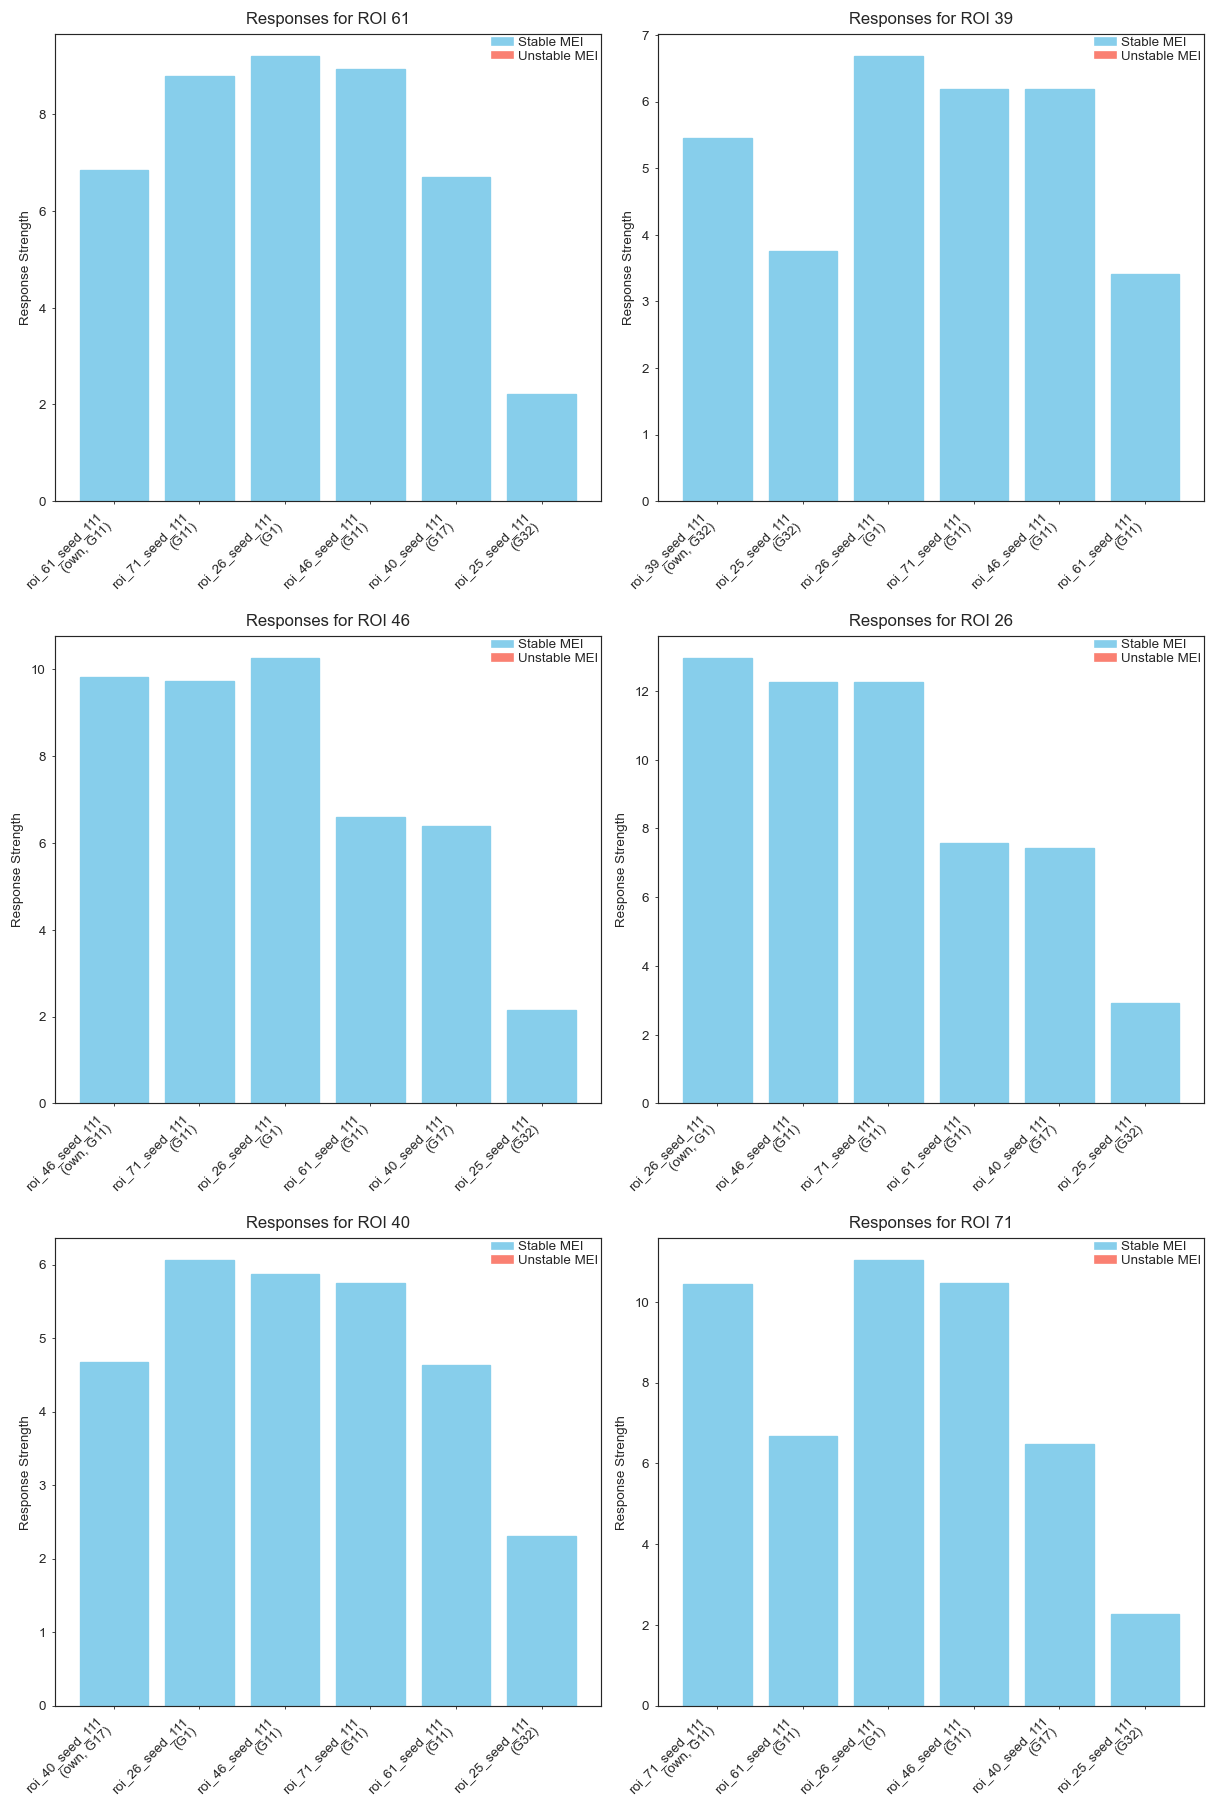

In [18]:
fig,axes = plt.subplots(3,2,figsize=(10,15))
axes = axes.flatten()

some_roi_ids = [61,39,46,26,40,71,25]
roi_id2mei_id,roi_id2info = select_subset_of_meis_for_each_roi(
    only_consider_these_rois =  some_roi_ids,
    mei_data_container=mei_data_container,
    neuron_data_dict=neuron_data_dict,
    new_session_id=new_session_id,
    readout_idx_wmei2rois=readout_idx_wmei2rois,
)
for i in range(len(some_roi_ids) - 1):
    fig,ax = ut.plot_responses_and_mei_info_one_roi(
        roi_id= some_roi_ids[i],
        roi_id2mei_ids = roi_id2mei_id,
        roi_id2info = roi_id2info,
        ax = axes[i],
    )

plotter.tight_layout()


All responses [9.891495704650879, 9.335443496704102, 10.057106971740723, 6.245594501495361, 2.3786303997039795, 1.3700239658355713]
all celltypes [1, 1, 9, 32, 32, 27]
all meis ['roi_5_seed_111', 'roi_94_seed_111', 'roi_68_seed_111', 'roi_39_seed_111', 'roi_56_seed_111', 'roi_51_seed_111']
All responses [11.5828275680542, 8.811214447021484, 11.540480613708496, 4.253217697143555, 1.7977564334869385, 0.7121112942695618]
all celltypes [17, 17, 13, 32, 32, 7]
all meis ['roi_7_seed_111', 'roi_22_seed_111', 'roi_62_seed_111', 'roi_39_seed_111', 'roi_41_seed_111', 'roi_15_seed_111']
All responses [4.421619415283203, 4.751136779785156, 7.42092752456665, 6.647367000579834, 3.2590413093566895, 0.5750154852867126]
all celltypes [31, 31, 9, 11, 32, 12]
all meis ['roi_8_seed_111', 'roi_81_seed_111', 'roi_68_seed_111', 'roi_46_seed_111', 'roi_56_seed_222', 'roi_84_seed_111']
All responses [5.446211814880371, 3.9921295642852783, 5.709826946258545, 4.218613624572754, 3.2625739574432373, 0.692785143852

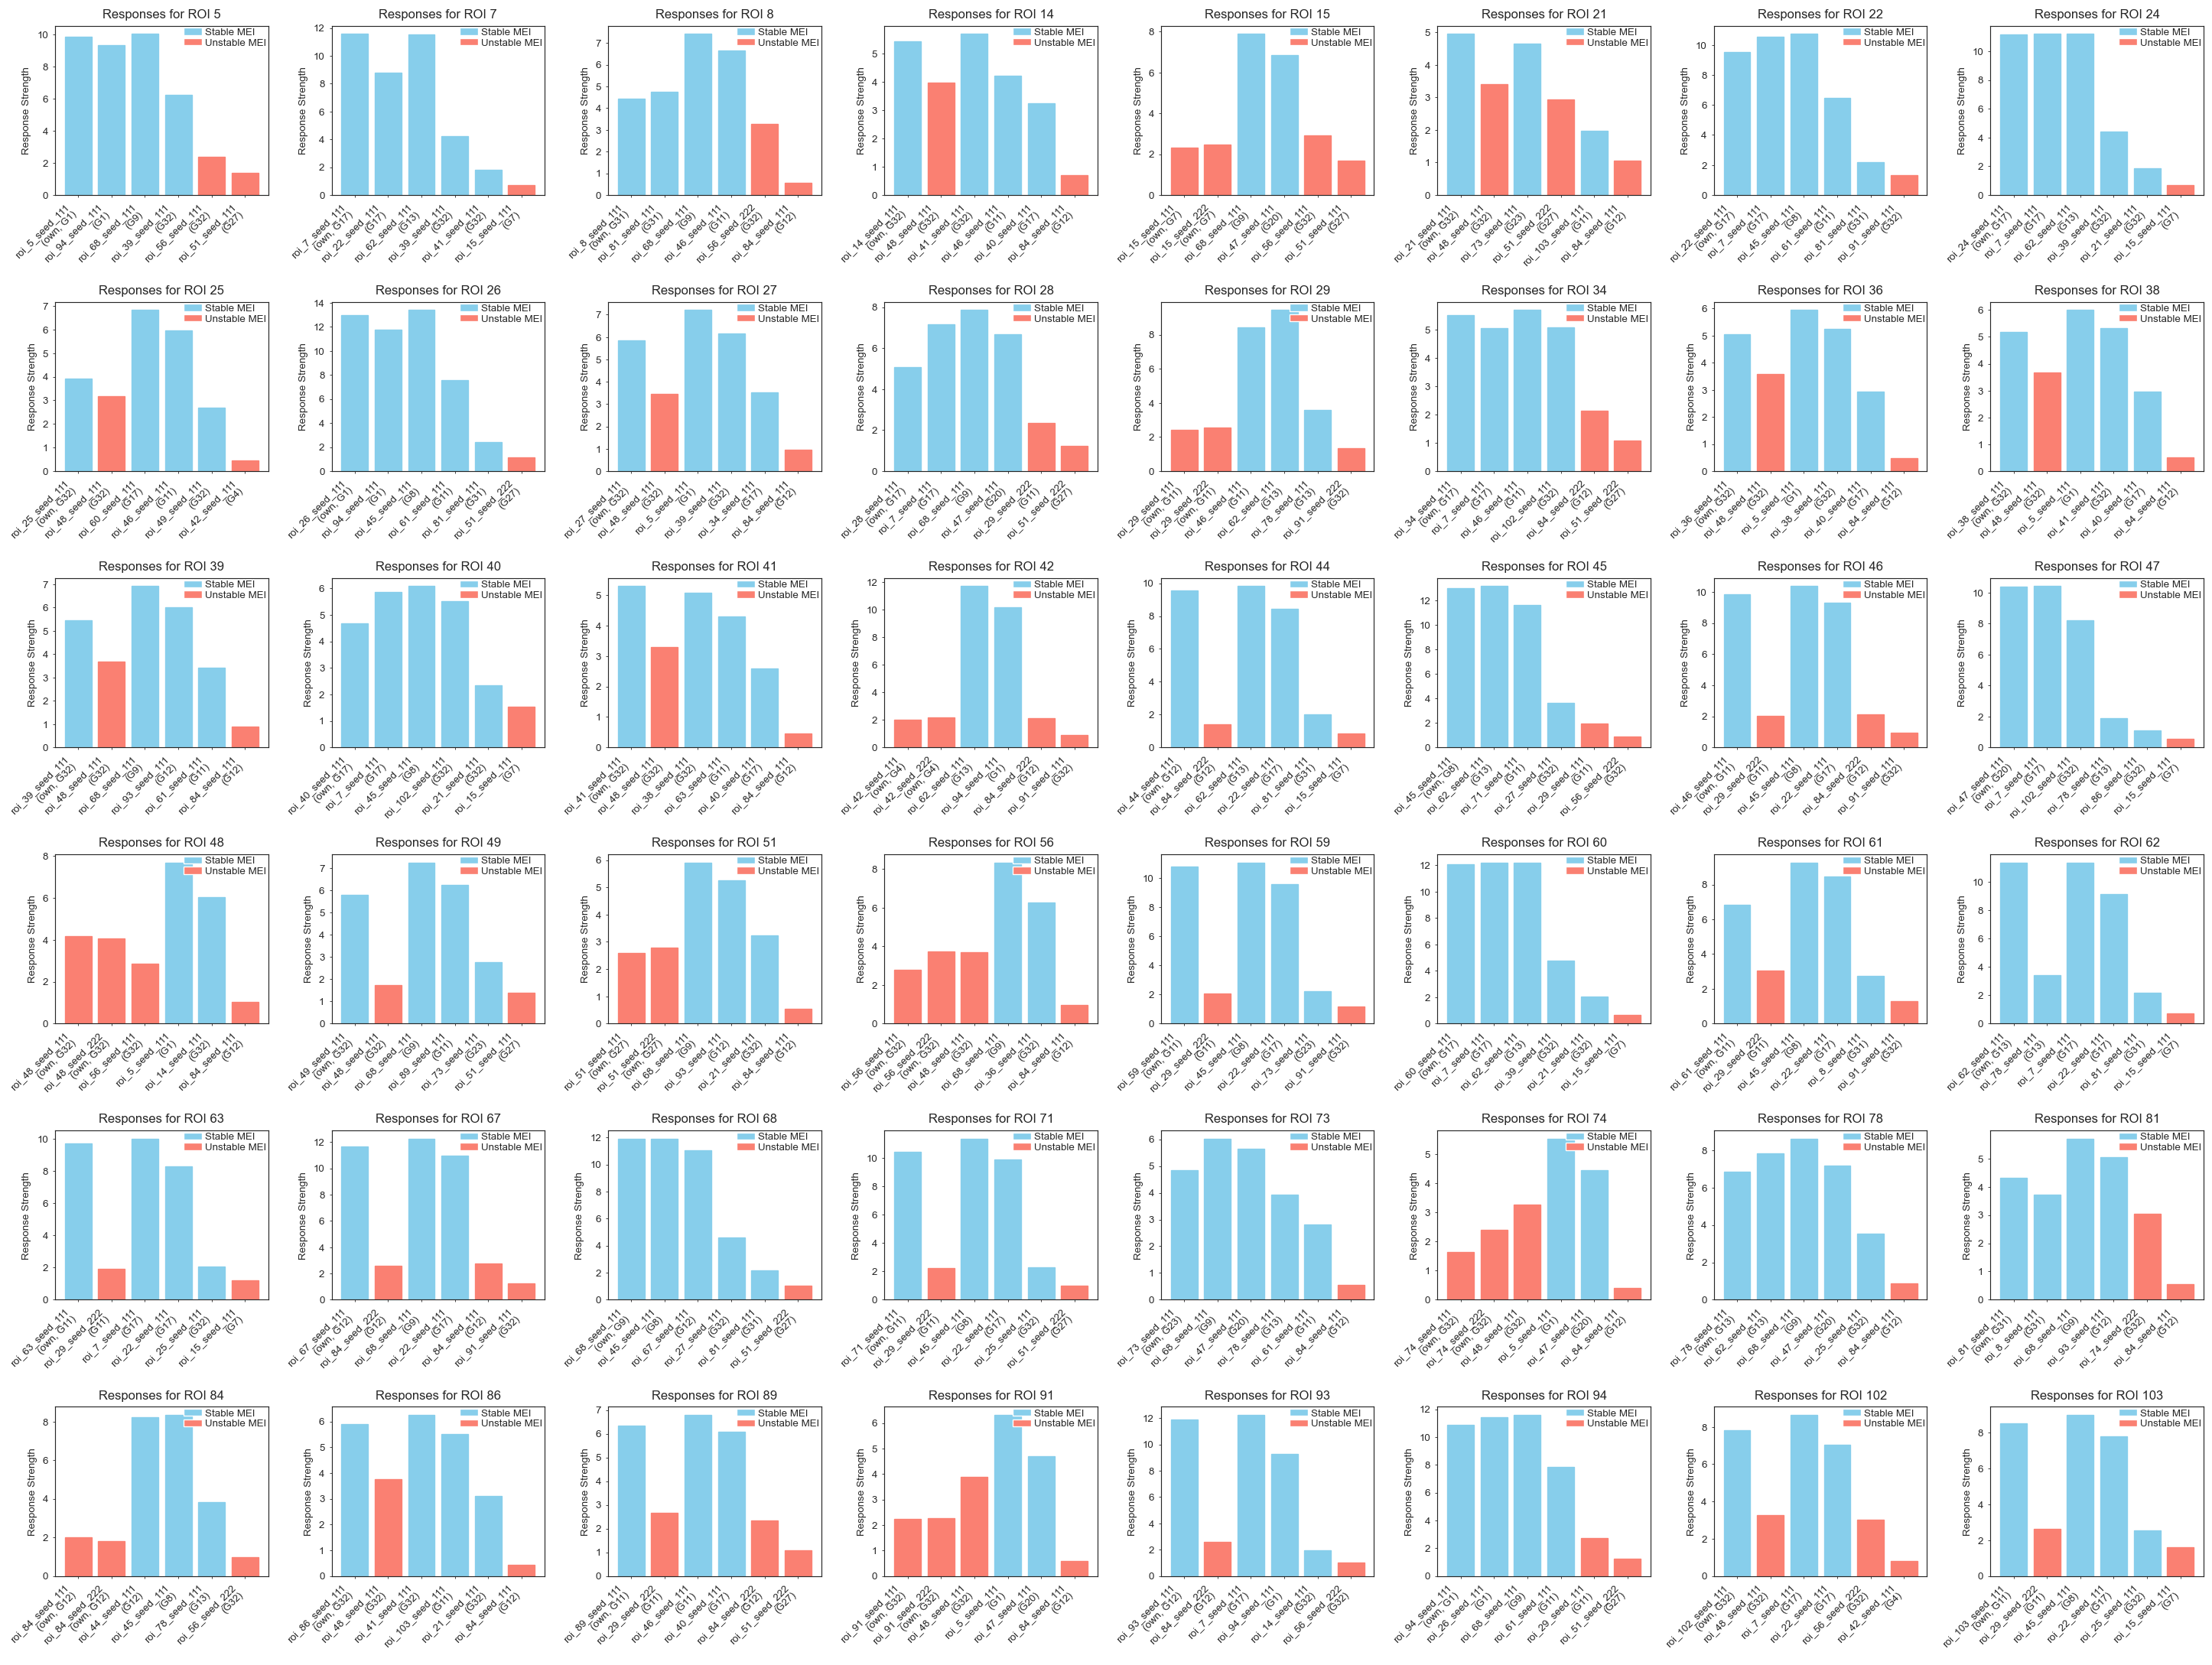

In [17]:
# lets look at all 
# Add this before your debugging section
mei_data_container_debug = mei_data_container.copy()

# If it contains large tensors or arrays, replace with placeholder values
if 'mei' in mei_data_container_debug.columns:
    mei_data_container_debug['mei'] = "<<TENSOR>>"
if 'temporal_kernels' in mei_data_container_debug.columns:
    mei_data_container_debug['temporal_kernels'] = "<<ARRAY>>"


def plot_all_rois(readout_idx_wmei2rois,
                  ):
    all_roi_ids = list(readout_idx_wmei2rois.values())


    roi_id2mei_id,roi_id2info = select_subset_of_meis_for_each_roi(
        only_consider_these_rois =  all_roi_ids,
        mei_data_container=mei_data_container_debug,
        neuron_data_dict=neuron_data_dict,
        new_session_id=new_session_id,
        readout_idx_wmei2rois=readout_idx_wmei2rois,
    )
    n_rows = np.sqrt(len(all_roi_ids)).astype(int)
    n_cols = int(np.ceil(len(all_roi_ids)/n_rows))
    fig,axes = plt.subplots(n_rows,n_cols,figsize=(n_cols* 3,n_rows*3))
    axes = axes.flatten()
    for ax,roi in zip(axes, all_roi_ids):
        _ = ut.plot_responses_and_mei_info_one_roi(
            roi_id= roi,
            roi_id2mei_ids = roi_id2mei_id,
            roi_id2info = roi_id2info,
            ax = ax,
        )


    plotter.tight_layout()

plot_all_rois(readout_idx_wmei2rois)

In [19]:
mei_data_container_debug.head()

,readout_idx,roi_id,mei_id,seed,mei,temporal_kernels,spatial_kernels,stability,responses_all_readout_idx,mean_responses_all_readout_idx
0,4,15,roi_15_seed_111,111,<<TENSOR>>,<<ARRAY>>,"[[[0.010039923, 0.010363647, -0.006646924, -0....",unstable,"[[0.6280285, 0.53008074, 1.1791885, 2.191737, ...","[1.4804952, 0.7121113, 0.93923724, 1.7343414, ..."
1,4,15,roi_15_seed_222,222,<<TENSOR>>,<<ARRAY>>,"[[[-0.033519145, -0.022821346, 0.008730012, 0....",unstable,"[[0.6489118, 0.5056874, 1.0499732, 1.999119, 1...","[1.7630123, 0.837072, 1.009346, 1.8474468, 2.4..."
2,12,29,roi_29_seed_111,111,<<TENSOR>>,<<ARRAY>>,"[[[0.014076945, 0.028721757, 0.051821496, 0.06...",unstable,"[[0.79568595, 0.46166706, 2.160111, 3.3756237,...","[1.6724008, 0.84996355, 0.87712896, 1.4650023,..."
3,12,29,roi_29_seed_222,222,<<TENSOR>>,<<ARRAY>>,"[[[-0.03466646, -0.025514608, 0.044529777, 0.1...",unstable,"[[0.73299044, 0.4316414, 1.9917675, 3.2428308,...","[1.6521015, 0.7821231, 0.7036186, 1.1699966, 2..."
4,20,42,roi_42_seed_111,111,<<TENSOR>>,<<ARRAY>>,"[[[0.08461799, 0.16195191, 0.1963179, 0.147239...",unstable,"[[0.51685363, 0.37705392, 1.1418451, 2.4665332...","[1.7960823, 0.74600816, 0.57876956, 0.98546237..."
